# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 02: Extracción y Transformación de Datos </center></h1>

**Fecha de Entrega:** 25 de septiembre de 2025, a las 23:59.

**Fecha de publicación**: 2 de septiembre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 02 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

Para esta tarea, queremos comprender y visualizar la distribución de aves migratorias en el territorio chileno. Específicamente, queremos entender las diferencias entre las migraciones de 2 especies en particular, el run-run y la dormilona tontita, a partir de los avistamientos registrados en eBird durante un periodo de 3 años y medio.

### 1.3 Recomendaciones
- Utiliza las librerías sugeridas en el notebook o justifica brevemente si incorporas otras.
- Revisa que todas las celdas se ejecuten en orden, desde el inicio, sin errores.
- Comenta tu código para explicar qué hace cada sección relevante.
- Asegúrate de que las visualizaciones sean fáciles de interpretar y tengan títulos y etiquetas adecuados.

### 1.4 Ejemplo de visualización

Esta tarea se enfoca en datos de aves. Para complementarla, les compartimos la siguiente página web, llamada "Bird Migration Explorer" que les permite visualizar, de una forma novedosa e interesante, las rutas de migración de aves en las Americas. Visiten la página para que vean cómo se puede visualizar datos de una manera interesante y novedosa, que podría ustedes usar en el futuro para sus proyectos.

In [1]:
#from IPython.display import IFrame
#IFrame("https://explorer.audubon.org/home?layersPanel=expand", width=900, height=600)

## 2. Datos

Los datos a utilizar provienen de la plataforma **[eBird](https://ebird.org/)**, una aplicación desarrollada por The Cornell Lab of Ornithology que permite a sus usuarios registrar y compartir avistamientos de aves en todo el mundo. La plataforma dispone de una API mediante la cual se pueden realizar consultas sobre avistamientos de aves recientes e históricos, especies según región, taxonomía, entre otros. 

### 2.1 Acceso a la API

Muchas API pueden utilizarse solo mediante el uso de una clave única, o "API key". Para conseguir una API key en eBird, primero debe ser usuario de la plataforma. Puede crear una cuenta aquí: https://secure.birds.cornell.edu/identity/account/create


Con una cuenta ya creada, puede ingresar a https://ebird.org/api/keygen para generar su llave. Debe llenar un formulario de solicitud al pedir su llave. Como sugerencia, puede llenar los campos con la siguiente información:

* **Organización:** Pontificia Universidad Católica de Chile
* **Título del Proyecto:** Tarea IMT2200 Introducción a Ciencia de Datos
* **Descripción:** "Uso educativo para exploración y análisis de distribución de aves migratorias en Chile."
* **Tipo de Proyecto:** Academic/Student
* **Casos de uso:** Materiales educativos y artíticos (...)

Debería recibir su llave inmediatamente después de enviar su solicitud. Como recomendación, puede revisar la documentación de la API en el siguiente link: https://documenter.getpostman.com/view/664302/S1ENwy59#intro

#### 2.2 Mapoteca de BCN

Para esta tarea queremos visualizar el movimiento de aves a lo largo de nuestro país. Para ello, también necesitaremos manejar datos geoespaciales: específicamente, trabajaremos con un mapa vectorial de Chile disponible en la página web de la Biblioteca del Congreso Nacional: https://www.bcn.cl/siit/mapas_vectoriales/index_html

Descargue el archivo `.zip` para las **Divisiones regionales** y descomprímalo. Dentro de esta carpeta, habrá un archivo llamado `Regional.shp`, que utilizaremos con `geopandas` para graficar nuestro mapa de Chile.

### 2.3 Librerías

Para esta tarea recomendamos al menos usar las librerías indicadas en la siguiente celda del Notebook. Puede agregar otras si lo estima conveniente para responder de mejor forma las preguntas de la Tarea.

In [2]:
import requests
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

# Aquí van las librerías adicionales:
import threading # Solo la uso para hacer múltiples llamadas al API simultaneas.

## 3. Desarrollo

Para cada una de las siguientes preguntas o actividades incluya una o más celdas de código y Markdown con las respuestas o comentarios necesarios para contestar la pregunta o lograr la actividad. Agregue sus celdas a continuación de cada pregunta para que el Notebook quede ordenado.

En el caso de gráficos, figuras o tablas, asegúrese que todas tengan título, etiquetas en los ejes o haya claridad de los contenidos.

### 3.1 Extracción de datos (1.5 puntos)

**(1 pto)** Vamos a crear nuestra base de datos con los avistamientos registrados en eBird dentro de Chile desde 2022 hasta 2025. Revise la documentación de la API y averigue cómo extraer los avistamientos de un día. Luego extraiga los avistamientos para todos los días desde el **1 de enero de 2022 hasta el 31 de julio de 2025.** Cuando haya logrado extraer todos los datos, guárdelos en un archivo CSV o parquet.

Responda:

**a) (0.2 pts)** ¿Cuántos avistamientos tiene su dataset?

**b) (0.3 pts)** Obtenga la cantidad de veces que se repite cada especie en su dataset y ordénelas de mayor a menor. ¿Qué pasa con la cantidad de avistamientos según especie? ¿Por qué?

**Recomendaciones:** 
* Puede usar la librería `datetime` para generar fechas: cree una lista con todas las fechas e itere sobre esta lista para hacer los llamados a la API.
* **Pruebe primero con uno o dos días** para verificar el funcionamiento de su código y de la API.
* Inspeccione la forma en la que vienen los datos.
* Vaya guardando los datos extraídos en archivos (CSV o parquet), de modo que no tenga que repetir los llamados en caso de algún error.

**Hint**: Los códigos regionales chilenos para la API son los siguientes,
* `regionCode = CL`
* `sppLocale = es_CL` (para obtener nombres chilenos de las aves)

**Desarrollo 3.1** 
> El siguiente código va a hacer todos los requests necesarios, compilarlos en un DataFrame, y guardarlos en un ".csv".

In [3]:
# Consigue información para poder hacer el request.
api_key = 'iv8q57gesn9f' # Mi key de API, sé que técnicamente no es seguro tenerla expuesta pero ¯\_(ツ)_/¯.
regionCode = 'CL' # Código de región de "Chile"
header = {"x-ebirdapitoken" : api_key} # Header donde va my API key.
parametros = {'sppLocale' : 'es_CL'} # Parametro para obtener nombres Chilenos.

# Esto guarda las fechas que voy a usar en una lista.
lista_fechas = []
fecha_inicio = datetime.date(2022, 1, 1) # Fecha de inicio (en formato año-mes-día).
fecha_fin = datetime.date(2025, 7, 31) # Fecha de fin deseado (en formato año-mes-día).
while fecha_inicio <= fecha_fin: # Este loop añade cada fecha que existe desde 2022-01-01 a 25-07-31 a la lista "lista_fechas".
    lista_fechas.append(fecha_inicio)
    fecha_inicio += datetime.timedelta(days=1)

# Genera una lista con todos los URLs que voy a usar para las requests.
lista_urls_para_requests = []
for fecha in lista_fechas:
    str_request = f'https://api.ebird.org/v2/data/obs/{regionCode}/historic/{fecha.year}/{fecha.month}/{fecha.day}'
    lista_urls_para_requests.append(str_request)

In [4]:
data_requests = [] # Lista vacía, almacenará la información de los requests hechos.
lock = threading.Lock()

# Crea una función para hacer las requests al API.
def llamada_api(url, parametros_para_request, headers_para_request):
    global data_requests
    respuesta = requests.get(url, params=parametros_para_request, headers=headers_para_request)
    with lock:
        data_requests.append(respuesta)

> El bloque abajo hace todas las requests y guarda el contenido no procesado en la variable 'data_requests', **SOLO CORRER UNA VEZ!!**.

In [5]:
threads = [] # Va a contener los threads creados en el siguiente loop.
for url in lista_urls_para_requests: # Crea un thread por cada url que tengo guardado para hacer requests.
    thread = threading.Thread(target=llamada_api, args=(url, parametros, header))
    threads.append(thread)
    thread.start()

for thread in threads: # Se asegura que todos los threads hayan terminado antes de parar, no estoy seguro si es necesario en notebooks.
    thread.join()

In [6]:
# Procesa la data que conseguí de los requests y la guarda en una lista.
data_procesada = []
for response in data_requests:
    data_procesada.append(response.json())

# Creo un DataFrame Vacío, lo lleno con la data de 'data_procesada'.
df_full = pd.DataFrame()
for data in data_procesada:
    temp_df = pd.DataFrame(data)
    df_full = pd.concat([df_full, temp_df], ignore_index=True)

# Convierto el archivo en un '.csv'.
df_full.to_csv('avistamientos_desde_2022-1-1_a_2025-7-31.csv', sep=',', encoding='utf-8', index=False)

> El siguiente bloque va a ver cuantas veces se repite cada avistamiento de especie de pájaro. Cuenta la cantidad de avistamientos para la pregunta 'a' y contiene el DataFrame para la pregunta 'b'.

In [7]:
# Leer archivo '.csv' para usar.
df_full = pd.read_csv('avistamientos_desde_2022-1-1_a_2025-7-31.csv', sep=',', encoding='utf_8', low_memory=False)

cantidad_total_avistamientos = int(df_full['howMany'].sum())

# Copia código de especie, nombre común, y cuantos fueron avistados.
df_n_avistamientos = df_full[['speciesCode', 'comName', 'howMany']].copy()
# Combina todos los avistamientos de una misma especie, sumando la cantidad de avistamientos.
df_n_avistamientos = df_n_avistamientos.groupby(['speciesCode', 'comName'])['howMany'].sum(numeric_only=False).reset_index()

df_n_avistamientos = df_n_avistamientos.sort_values('howMany', ascending=False, ignore_index=True)

**Respuesta 3.1 a)**
> La respuesta está en el print de abajo. :P 

In [8]:
# Respuesta a
print(f'La cantidad total de pajaros avistados es de {cantidad_total_avistamientos} avistamientos.')
print(f'La cantidad total de avistamientos sin contar pajaros individualmente, solo son {len(df_full)} avistamientos')

La cantidad total de pajaros avistados es de 1651437 avistamientos.
La cantidad total de avistamientos sin contar pajaros individualmente, solo son 129824 avistamientos


**Respuesta 3.1 b)** 
> En este datafame se puede ver que la Fardela negra es el pájaro más avistado por mucho, teniendo más del triple de avistamientos que el pájaro anterior, el Guanay.

In [9]:
# Respuesta b
df_n_avistamientos.head()

,speciesCode,comName,howMany
0,sooshe,Fardela negra,205447.0
1,guacor1,Guanay,89704.0
2,impcor1,Cormorán imperial,80022.0
3,sander,Playero blanco,66564.0
4,hudgod,Zarapito de pico recto,64869.0


### 3.2 Tranformación (1 punto)

**a) (0.5 pts)** Transforme la columna `obsDt` de string a un objeto de tipo `datetime` únicamente con año, mes y día (YYYY-MM-DD). Luego, agregue las siguientes nuevas columnas:
* `month` con únicamente el mes del avistamiento (puede dejar el mes como número entero de 1 a 12).
* `year-month` con el mes y año fecha en formato YYYY-MM

**Desarrollo 3.2** 
> Aquí primero añado la columna "month", después "year-month" y por último transformo la columna "obsDt" en objetos de tipo "datetime".

In [10]:
# Respuesta
df_full_copia = df_full.copy()

# Cambiar formato, el formato actual es "YYYY-MM-DD hh:mm".
# Como solo nos interesa "YYYY-MM-DD", sacamos la hora.
df_full_copia['obsDt'] = df_full_copia['obsDt'].str.slice(0,10)
# Ahora está en formato "YYYY-MM-DD".

# Creo columna de "month".
df_full_copia['month'] = (df_full_copia['obsDt'].str.slice(5,7).str.lstrip('0')).astype('Int64')

# Creo columna de "year-month" vacía.
df_full_copia['year-month'] = None

# Ahora añado la data a "year-month" y cambio "obsDt".
for i,row in df_full_copia.iterrows():
    fecha_raw = row['obsDt']
    if type(fecha_raw) != float:
        # "year-month".
        lista_fecha = fecha_raw.split('-')
        lista_fecha[0] = int(lista_fecha[0].lstrip('0'))
        lista_fecha[1] = int(lista_fecha[1].lstrip('0')) 
        df_full_copia.loc[i,'year-month'] = (datetime.datetime(lista_fecha[0], lista_fecha[1], 1)).strftime("%Y-%m")
        # "obsDt"
        lista_fecha[2] = int(lista_fecha[2].lstrip('0'))
        df_full_copia.loc[i,'obsDt'] = (datetime.datetime(lista_fecha[0], lista_fecha[1], lista_fecha[2])).strftime("%Y-%m-%d")

In [11]:
# Guardar cambios en otro ".csv".
df_full_copia.to_csv('3-2_MODIFICADO_av_de_2022-1-1_a_2025-7-31.csv', sep=',', encoding='utf-8', index=False)

**Respuesta 3.2 a)**
> Como se puede ver en el bloque de abajo, la columna "obsDt" es un objeto y existen las columnas "month" y "year-month".

In [12]:
print(type(df_full_copia.iloc[0]['obsDt']))
df_full_copia.head(1)


<class 'str'>


,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,errors,month,year-month
0,gryfin1,Chirihue común,Sicalis luteola,L17340060,"Esmeralda 582, Perquenco CL-La Araucanía (-38....",2022-01-05,2.0,-38.420518,-72.379653,True,False,True,S100202073,NaN,NaN,1,2022-01


**b) (0.5 pts)** Averigue cómo tranformar su DataFrame de Pandas en un GeoDataFrame de GeoPandas. Para esto, utilice las columnas `lat`y `lng` para generar los puntos de la nueva columna `geometry`. Para las visualizaciones siguientes utilizaremos el Coordinate Reference System (CRS) EPSG 4326 (también llamado [WGS 84](https://es.wikipedia.org/wiki/WGS84)). Asegúrese que sus coordenadas correspondan a este CRS al crear su GeoDataFrame.


> Aquí abro el ".csv" que guardé anteriormente, y simplemente creo el GeoDataFrame a partir de ese. Yippee!

In [13]:
# Respuesta
# Primero abro mi archivo ".csv" guardado anteriormente.
df_no_geo = pd.read_csv('3-2_MODIFICADO_av_de_2022-1-1_a_2025-7-31.csv', sep=',', encoding='utf_8', low_memory=False)

In [14]:
# Aqui simplemente lo convierto en GeoDataFrame usando las columnas "lng" y "lat".
df_geo = gpd.GeoDataFrame(df_no_geo, geometry=gpd.points_from_xy(df_no_geo['lng'], df_no_geo['lat']), crs="EPSG:4326")
# df_geo.plot()

### 3.3 Exploración del dataset (1 punto)

**a) (0.3 pts)** Utilice `geopandas` para leer el archivo `Regional.shp` descargado de BCN. Asegúrese de que su CRS sea el mismo que utilizó en la sección anterior.

**Respuesta 3.3 a)**

In [15]:
# Respuesta
# Leo el archivo del mapa y lo convierto al CRS correcto.
mapa = gpd.read_file('data/Regional.shp')
mapa_fixed = mapa.to_crs(4326)
# mapa_fixed.plot()

**b) (0.7 pts)** Grafique un mapa de Chile con todos los avistamientos de su dataset como puntos en el mapa. Comente: ¿Cómo se distribuyen estos avistamientos? ¿Hay lugares en Chile donde haya una menor densidad de datos? ¿Cuáles? 

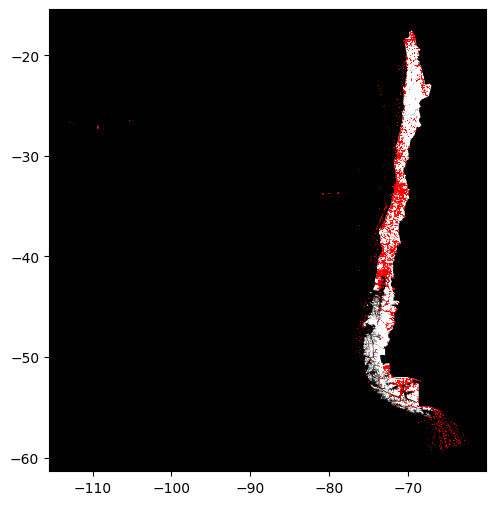

In [16]:
# Creo un subplot para colocar los 2 plots.
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_facecolor('black')

# Hago plot del mapa y la data de avistamientos en el mismo subplot.
mapa_fixed.plot(ax=ax, color='white')
df_geo.plot(ax=ax, markersize=0.1, lw=0, color='red')
plt.show()

**Respuesta 3.3 b)**
> Se puede ver que la mayoría de avistamientos está entre La Serena y Chiloé, los lugares con menor densidad son las partes al sur de Chiloé hasta Punta Arenas, y también desde el norte de La Serena hasta Arica.

### 3.4 Visualización de migraciones (2.5 puntos)

**a) (0.2 pts)** Vamos a inspeccionar los avistamientos de las siguientes 2 especies en particular:

* Run-run [(*Hymenops perspicillatus*)](https://www.avesdechile.cl/171.htm)
* Dormilona tontita [(*Muscisaxicola maclovianus*)](https://www.avesdechile.cl/043.htm)

Primero, genere dos nuevos dataframes con los avistamientos de cada especie por separado.

**Respuesta 3.4 a)**
> Aquí creo los Dataframes de cada pajaro a partir de el DataFrame limpiado anteriormente.

In [17]:
# Respuesta

# Empiezo con abrir el ".csv" que usaré como base.
df_all_pajaros = pd.read_csv('3-2_MODIFICADO_av_de_2022-1-1_a_2025-7-31.csv', sep=',', encoding='utf_8', low_memory=False)

# Ahora creo copias de ese DataFrame base que solo tengan los pajaros respectivos.
df_runrun = df_all_pajaros.loc[df_all_pajaros['speciesCode'] == 'spetyr1'].copy().reset_index(drop=True)
df_dormil = df_all_pajaros.loc[df_all_pajaros['speciesCode'] == 'dafgrt1'].copy().reset_index(drop=True)

In [18]:
# DataFrame del Run-run.
df_runrun.head(1)

,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,errors,month,year-month
0,spetyr1,Run-run,Hymenops perspicillatus,L17401377,Isla Teja--Humedal Sur,2022-01-05,1.0,-39.820261,-73.25806,True,False,False,S100197285,NaN,NaN,1.0,2022-01


In [19]:
# DataFrame de la Dormilona tontita.
df_dormil.head(1)

,speciesCode,comName,sciName,locId,locName,obsDt,howMany,lat,lng,obsValid,obsReviewed,locationPrivate,subId,exoticCategory,errors,month,year-month
0,dafgrt1,Dormilona tontita,Muscisaxicola maclovianus,L1030753,PN Torres del Paine--Lago Grey (sector sur),2022-01-05,2.0,-51.11651,-73.122983,True,False,False,S101584897,NaN,NaN,1.0,2022-01


**b) (0.8 pts)** Para cada una de estas especies, agrupe los datos según `year-month`. Luego, realice un gráfico que muestre la cantidad de avistamientos en el tiempo, empezando desde enero del 2022 hasta julio de 2025. Responda: ¿cómo varía cantidad de avistamientos para estas dos especies? ¿Cuáles son sus diferencias?

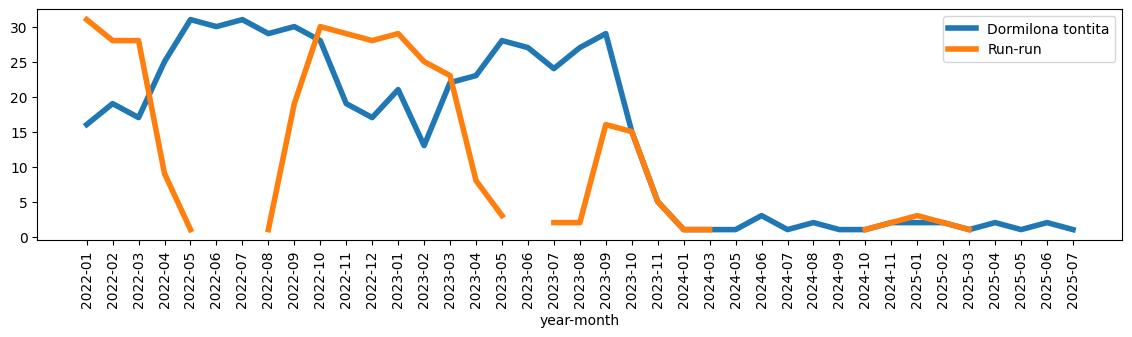

In [21]:
# Respuesta

# El subplot principal.
fig, ax = plt.subplots(figsize=(14,3))

# Esto recopila la información de cuantos avistamientos hay de cada pajaro en un 'year-month'.
dormil_counts = df_dormil['year-month'].value_counts().sort_index()
runrun_counts = df_runrun['year-month'].value_counts().sort_index()

# Concatena ambos 'counts' en un solo DataFrame y lo plottea.
df_ambos = pd.concat([dormil_counts, runrun_counts], axis=1)
df_ambos.columns = ['Dormilona tontita', 'Run-run']
df_ambos.plot(ax=ax, linewidth=4, figsize=(14,3))

# Esto simplemente encuentra y muestra todos los indices del DataFrame,
# Si no hago esto, algunos "year-month"s son ocultados.
lista_yearmonth = []
for i, row in df_ambos.iterrows():
    lista_yearmonth.append(i)
plt.xticks(np.arange(0,len(lista_yearmonth),1))
ax.set_xticklabels(lista_yearmonth, rotation=90)

plt.legend()
plt.show()

**Respuesta 3.4 b)**
> Se puede ver que el número de avistamientos fluctua, los avistamientos del Run-run básicamente desapareciendo cada año entre mayo y agosto, mientras que la Dormilona tontita tiene más avistamientos de lo normal en esas fechas, aunque no desaparece en ningún momento.
> Una de las mayores diferencias en la que me puedo fijar es una que mencioné anteriormente, mientras que los avistamientos de ambas aves fluctuan, los avistamientos del Run-run bajan lo suficiente para no tener avistamientos en ciertos meses del año.

**b) (1 pto)** Grafique en un mapa de Chile la ubicación de cada avistamiento para cada especie mencionada por separado. Utilice el color de cada punto como indicador del mes de avistamiento (columna `month`). Para esto, utilice un **colormap cíclico** para representar los meses del año. Puede utilizar el colormap disponible en la siguiente celda, o bien utilizar otro (siempre y cuando sea cíclico).

**Respuesta 3.4 b) 2??? Hay dos preguntas b en 3.4 lol**

In [22]:
import matplotlib.colors as mcolors
colors = ["black", "gold", "black"]
positions = [0, 0.5, 1]

# Creamos un colormap cíclico para representar meses del año
custom_cmap = mcolors.LinearSegmentedColormap.from_list("cyclic_cmap", list(zip(positions, colors)))

In [23]:
# Respuesta
mapa = gpd.read_file('data/Regional.shp')
mapa_fixed = mapa.to_crs(4326)

df_geo_runrun = gpd.GeoDataFrame(df_runrun, geometry=gpd.points_from_xy(df_runrun['lng'], df_runrun['lat']), crs="EPSG:4326")
df_geo_runrun = df_geo_runrun.sort_values(by='month', ascending=True)


df_geo_dormil = gpd.GeoDataFrame(df_dormil, geometry=gpd.points_from_xy(df_dormil['lng'], df_dormil['lat']), crs="EPSG:4326")
df_geo_dormil = df_geo_dormil.sort_values(by='month', ascending=True)

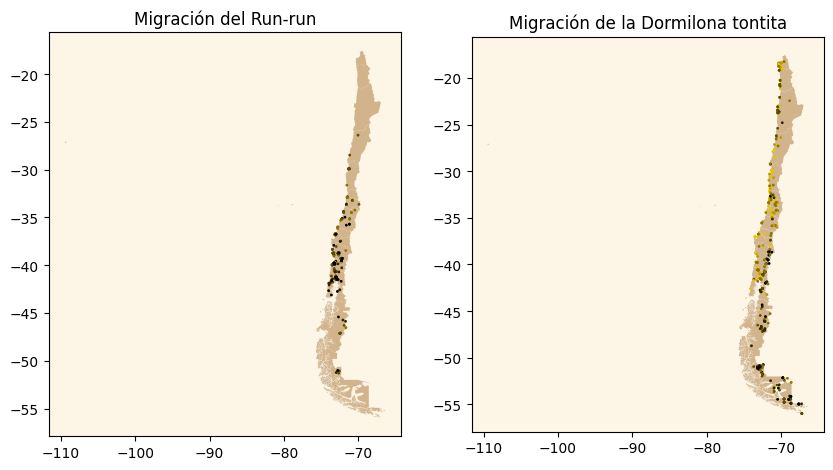

In [24]:
fig, ax = plt.subplots(1, 2, figsize=(10, 6))

ax[0].set_facecolor('oldlace')
ax[1].set_facecolor('oldlace')
#scatter_runrun = plt.scatter(x, y, c=colors, cmap=
mapa_fixed.plot(ax=ax[0], color='tan')
df_geo_runrun.plot(ax=ax[0], column='month', markersize=1, cmap=custom_cmap, label='wagh')

mapa_fixed.plot(ax=ax[1], color='tan')
df_geo_dormil.plot(ax=ax[1], column='month', markersize=1, cmap=custom_cmap)

ax[0].set_title('Migración del Run-run')
ax[1].set_title('Migración de la Dormilona tontita')

plt.show()

**c) (0.5 pts)** Describa las migraciones de estas dos especies. ¿Cómo se diferencian?

**Respuesta 3.4 c)**
> El colormap cíclico es negro al principio y fin del año (verano) y dorado en la mitad del año (invierno).\
> \
> Para la migración del Run-run, dado a que las avistaciones en Chile paran a mitad de año podría asumir que migra a otros países durante el otoño e invierno, pero dado a que solo tengo la información de Chile esto es solo especulación.\
> \
> Para la migración de la Dormilona tontita, puedo ver que durante el verano may varias avistaciones en el sur y en el invierno hay más avistaciones en el norte, lo cúal me imagino que es por la temperatura.\
> \
> En lo que más se diferencian las migraciones del Run-run y la Dormilona tontita son que la migración del Run-run es más "brusca", básicamente desapareciendo de Chile en el invierno, mientras que la migración de la Dormilona tontita es más "relajada", aún habiendo algunos avistamientos en el sur durante los tiempos cerca del invierno y avistamientos en el norte cerca del verano.